# Họ và Tên: Trần Tất Nguyên
# MSSV: 31251020719

# Bài tập Buổi 7 — Logistic Regression vs Linear Regression trên tập Titanic

## 0. Chuẩn bị môi trường

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

print("Sẵn sàng")

Sẵn sàng


## 1. Tải và chuẩn bị dữ liệu

In [2]:
try:
    df = sns.load_dataset('titanic')
    print("Đã tải từ seaborn")
except:
    df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
    print("Đã tải từ url")

print(f"\nKích thước dataset: {df.shape}")
print(f"\nCác cột: {list(df.columns)}")

display(df.head())

Đã tải từ seaborn

Kích thước dataset: (891, 15)

Các cột: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Xử lý dữ liệu

In [3]:
df_clean = df.drop(columns=['class', 'who', 'adult_male', 'alive', 'embark_town', 'deck'])
df_clean = df_clean.dropna(subset=['survived'])
y = df_clean['survived']
X = df_clean.drop(columns=['survived'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTỷ lệ lớp (survived):")
print(y.value_counts(normalize=True) * 100)


print(f"\nMissing values:")
print(X.isnull().sum())

X shape: (891, 8)
y shape: (891,)

Tỷ lệ lớp (survived):
survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64


## 3. Chia tập dữ liệu (train/val/test)

In [4]:
# Chia train:val:test = 70:15:15 
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=42
)

print(f"Train/Val/Test shape: {X_train.shape}, {X_val.shape}, {X_test.shape}")
print("\nTỷ lệ sống sót:")
print("Train:", y_train.mean())
print("Val:  ", y_val.mean())
print("Test: ", y_test.mean())

Train/Val/Test shape: (623, 8), (134, 8), (134, 8)

Tỷ lệ sống sót:
Train: 0.38362760834670945
Val:   0.3880597014925373
Test:  0.3805970149253731


## 4. Xây dựng Pipeline tiền xử lý

In [5]:
num_cols = ['age', 'sibsp', 'parch', 'fare']
cat_cols = ['sex', 'embarked']
ord_cols = ['pclass']

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', pipe_num, num_cols),
    ('cat', pipe_cat, cat_cols),
    ('ord', 'passthrough', ord_cols),
])

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_val_processed shape: {X_val_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

feature_names = preprocessor.get_feature_names_out()
print(f"\nFeature names: {list(feature_names)}")

X_train_processed shape: (623, 10)
X_val_processed shape: (134, 10)
X_test_processed shape: (134, 10)

Feature names: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


## 5. Huấn luyện Logistic Regression

In [6]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_processed, y_train)

# Dự đoán trên các tập
y_train_pred_lr = log_reg.predict(X_train_processed)
y_val_pred_lr = log_reg.predict(X_val_processed)
y_test_pred_lr = log_reg.predict(X_test_processed)

# Dự đoán xác suất 
y_train_proba_lr = log_reg.predict_proba(X_train_processed)[:, 1]
y_val_proba_lr = log_reg.predict_proba(X_val_processed)[:, 1]
y_test_proba_lr = log_reg.predict_proba(X_test_processed)[:, 1]

print("✓ Logistic Regression đã huấn luyện xong")
print(f"\nWeights: {log_reg.coef_[0]}")
print(f"Bias: {log_reg.intercept_[0]}")

✓ Logistic Regression đã huấn luyện xong

Weights: [-0.45497017 -0.27270611 -0.1174219   0.05713762  1.32345248 -1.32441338
  0.00714603  0.37951765 -0.38762457 -1.08597164]
Bias: 2.7051567877523386


## 6. Huấn luyện Linear Regression

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

# Dự đoán trên các tập
y_train_pred_linreg = lin_reg.predict(X_train_processed)
y_val_pred_linreg = lin_reg.predict(X_val_processed)
y_test_pred_linreg = lin_reg.predict(X_test_processed)

y_train_proba_linreg = np.clip(y_train_pred_linreg, 0, 1)
y_val_proba_linreg = np.clip(y_val_pred_linreg, 0, 1)
y_test_proba_linreg = np.clip(y_test_pred_linreg, 0, 1)

# Chuyển về class (threshold = 0.5)
y_train_pred_linreg_class = (y_train_proba_linreg >= 0.5).astype(int)
y_val_pred_linreg_class = (y_val_proba_linreg >= 0.5).astype(int)
y_test_pred_linreg_class = (y_test_proba_linreg >= 0.5).astype(int)

print("Linear Regression đã huấn luyện xong")
print(f"\nWeights: {lin_reg.coef_}")
print(f"Bias: {lin_reg.intercept_}")

Linear Regression đã huấn luyện xong

Weights: [-0.0695315  -0.03504039 -0.02494441  0.00662055  0.25285473 -0.25285473
 -0.0026152   0.06764664 -0.06503143 -0.17804251]
Bias: 0.9426400565673827


## 7. Đánh giá Logistic Regression

In [8]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    
   
    print(f"{model_name}".center(30,"-"))
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")
    
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': auc}

# Đánh giá trên test set
print("LOGISTIC REGRESSION - ĐÁNH GIÁ")

lr_results_train = evaluate_model(y_train, y_train_pred_lr, y_train_proba_lr, "Train Set")
lr_results_val = evaluate_model(y_val, y_val_pred_lr, y_val_proba_lr, "Validation Set")
lr_results_test = evaluate_model(y_test, y_test_pred_lr, y_test_proba_lr, "Test Set")

LOGISTIC REGRESSION - ĐÁNH GIÁ
----------Train Set-----------
Accuracy:  0.8010
Precision: 0.7674
Recall:    0.6904
F1-score:  0.7269
ROC-AUC:   0.8561

Confusion Matrix:
[[334  50]
 [ 74 165]]
TN: 334, FP: 50, FN: 74, TP: 165
--------Validation Set--------
Accuracy:  0.8284
Precision: 0.7544
Recall:    0.8269
F1-score:  0.7890
ROC-AUC:   0.8936

Confusion Matrix:
[[68 14]
 [ 9 43]]
TN: 68, FP: 14, FN: 9, TP: 43
-----------Test Set-----------
Accuracy:  0.7761
Precision: 0.7442
Recall:    0.6275
F1-score:  0.6809
ROC-AUC:   0.8160

Confusion Matrix:
[[72 11]
 [19 32]]
TN: 72, FP: 11, FN: 19, TP: 32


## 8. Đánh giá Linear Regression

In [9]:
print("LINEAR REGRESSION - ĐÁNH GIÁ")

linreg_results_train = evaluate_model(y_train, y_train_pred_linreg_class, y_train_proba_linreg, "Train Set")
linreg_results_val = evaluate_model(y_val, y_val_pred_linreg_class, y_val_proba_linreg, "Validation Set")
linreg_results_test = evaluate_model(y_test, y_test_pred_linreg_class, y_test_proba_linreg, "Test Set")

LINEAR REGRESSION - ĐÁNH GIÁ
----------Train Set-----------
Accuracy:  0.7978
Precision: 0.7604
Recall:    0.6904
F1-score:  0.7237
ROC-AUC:   0.8544

Confusion Matrix:
[[332  52]
 [ 74 165]]
TN: 332, FP: 52, FN: 74, TP: 165
--------Validation Set--------
Accuracy:  0.8358
Precision: 0.7778
Recall:    0.8077
F1-score:  0.7925
ROC-AUC:   0.8878

Confusion Matrix:
[[70 12]
 [10 42]]
TN: 70, FP: 12, FN: 10, TP: 42
-----------Test Set-----------
Accuracy:  0.7612
Precision: 0.7021
Recall:    0.6471
F1-score:  0.6735
ROC-AUC:   0.8125

Confusion Matrix:
[[69 14]
 [18 33]]
TN: 69, FP: 14, FN: 18, TP: 33


## 9. So sánh hai mô hình

In [10]:
comparison_data = {
    'Logistic Regression (Train)': lr_results_train,
    'Logistic Regression (Val)': lr_results_val,
    'Logistic Regression (Test)': lr_results_test,
    'Linear Regression (Train)': linreg_results_train,
    'Linear Regression (Val)': linreg_results_val,
    'Linear Regression (Test)': linreg_results_test,
}

comparison_df = pd.DataFrame(comparison_data).T

print("SO SÁNH LOGISTIC REGRESSION VS LINEAR REGRESSION")
print("-"*80)
print(comparison_df.round(4))

SO SÁNH LOGISTIC REGRESSION VS LINEAR REGRESSION
--------------------------------------------------------------------------------
                             Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression (Train)    0.8010     0.7674  0.6904  0.7269   0.8561
Logistic Regression (Val)      0.8284     0.7544  0.8269  0.7890   0.8936
Logistic Regression (Test)     0.7761     0.7442  0.6275  0.6809   0.8160
Linear Regression (Train)      0.7978     0.7604  0.6904  0.7237   0.8544
Linear Regression (Val)        0.8358     0.7778  0.8077  0.7925   0.8878
Linear Regression (Test)       0.7612     0.7021  0.6471  0.6735   0.8125


## 10. Confusion matrix

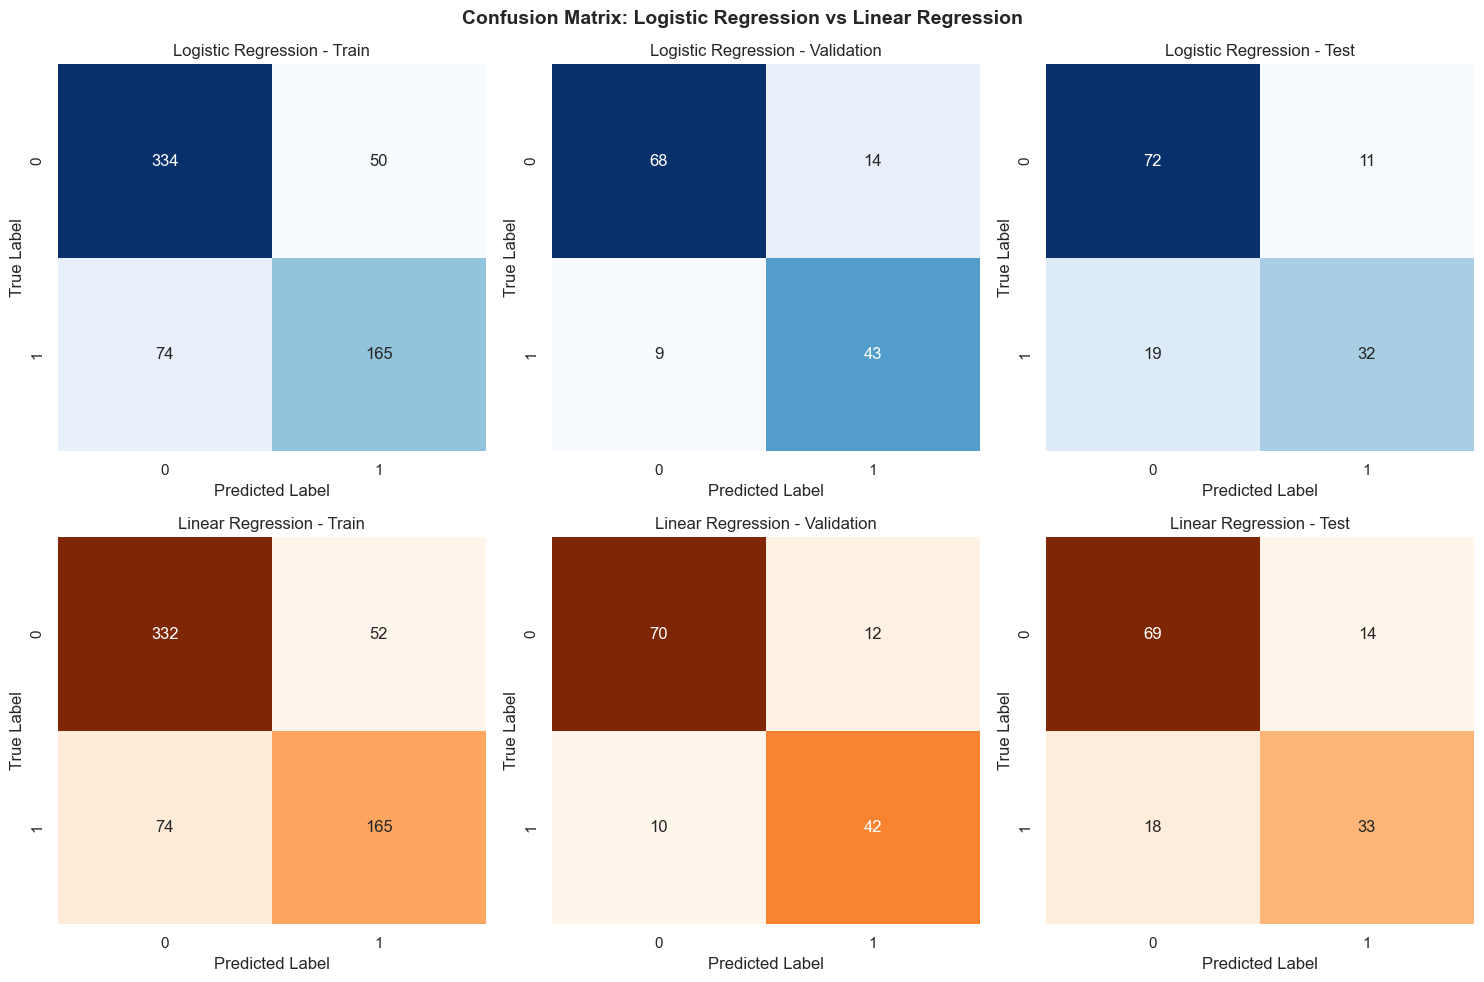

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Confusion Matrix: Logistic Regression vs Linear Regression', fontsize=14, fontweight='bold')

cms_lr = [
    confusion_matrix(y_train, y_train_pred_lr),
    confusion_matrix(y_val, y_val_pred_lr),
    confusion_matrix(y_test, y_test_pred_lr),
]

for idx, (cm, title) in enumerate(zip(cms_lr, ['Train', 'Validation', 'Test'])):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, idx], cbar=False)
    axes[0, idx].set_title(f'Logistic Regression - {title}')
    axes[0, idx].set_ylabel('True Label')
    axes[0, idx].set_xlabel('Predicted Label')

cms_linreg = [
    confusion_matrix(y_train, y_train_pred_linreg_class),
    confusion_matrix(y_val, y_val_pred_linreg_class),
    confusion_matrix(y_test, y_test_pred_linreg_class),
]

for idx, (cm, title) in enumerate(zip(cms_linreg, ['Train', 'Validation', 'Test'])):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[1, idx], cbar=False)
    axes[1, idx].set_title(f'Linear Regression - {title}')
    axes[1, idx].set_ylabel('True Label')
    axes[1, idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 11. Vẽ ROC Curve

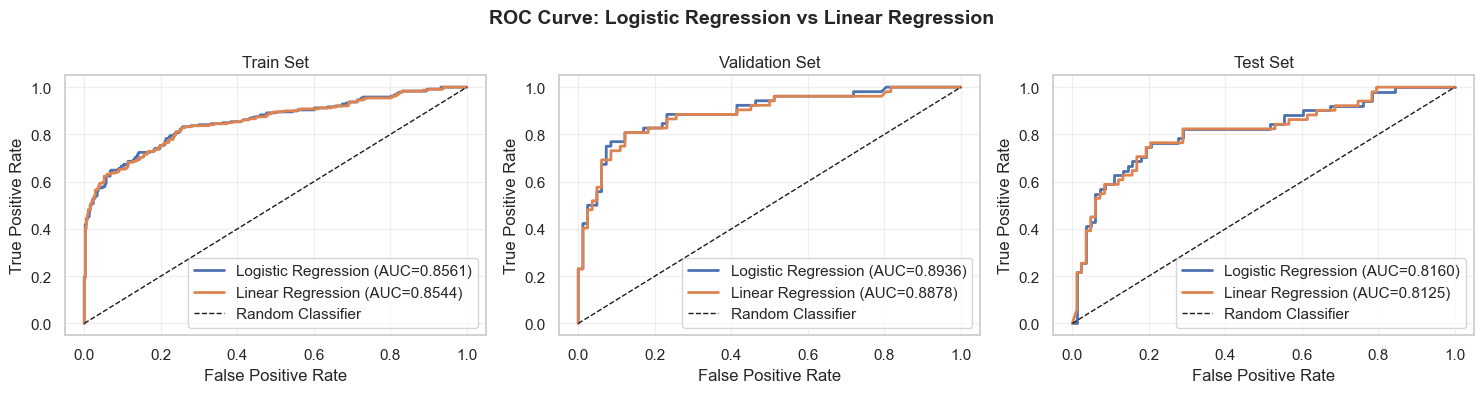

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ROC Curve: Logistic Regression vs Linear Regression', fontsize=14, fontweight='bold')

datasets = [
    (y_train, y_train_proba_lr, y_train_proba_linreg, 'Train'),
    (y_val, y_val_proba_lr, y_val_proba_linreg, 'Validation'),
    (y_test, y_test_proba_lr, y_test_proba_linreg, 'Test'),
]

for idx, (y_true, y_proba_lr, y_proba_linreg, title) in enumerate(datasets):
    ax = axes[idx]
    
    # Logistic Regression ROC
    fpr_lr, tpr_lr, _ = roc_curve(y_true, y_proba_lr)
    auc_lr = roc_auc_score(y_true, y_proba_lr)
    ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.4f})', linewidth=2)
    
    # Linear Regression ROC
    fpr_linreg, tpr_linreg, _ = roc_curve(y_true, y_proba_linreg)
    auc_linreg = roc_auc_score(y_true, y_proba_linreg)
    ax.plot(fpr_linreg, tpr_linreg, label=f'Linear Regression (AUC={auc_linreg:.4f})', linewidth=2)
    
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} Set')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Nhận xét tổng hợp

#### **So sánh metrics**

- Trên **Train set**: Logistic Regression nhỉnh hơn Linear về Accuracy (0.8010 vs 0.7978) và Precision nhưng hai mô hình gần như tương đương
- Trên **Val set**: Linear Regression nhỉnh hơn về Accuracy (0.8358 vs 0.8284) và F1 (0.7925 vs 0.7890) trong khi Logistic có Recall cao hơn (0.8269 vs 0.8077)
- Trên **Test set**: Logistic Regression rõ ràng tốt hơn về Accuracy (0.7761 vs 0.7612), Precision (0.7442 vs 0.7021) và F1 (0.6809 vs 0.6735)
- **ROC-AUC**: Logistic Regression cao hơn trên cả ba tập dù chênh lệch không lớn (~0.002–0.006)

#### **Lựa chọn mô hình**

**Trọng tâm bài toán:** Titanic là bài toán phân loại nhị phân. Logistic Regression được thiết kế cho loại bài toán này còn Linear Regression vốn dành cho hồi quy

**Output** Logistic Regression trả về xác suất thực sự trong [0, 1] qua hàm sigmoid. Linear Regression cho giá trị liên tục và sau đó phải clip thủ công về [0, 1] 

**Ổn định hơn trên dữ liệu mới:** Kết quả Test set cho thấy Logistic Regression tổng quát hóa tốt hơn (chênh lệch Accuracy giữa Val và Test của Logistic (khoảng 0.005) nhỏ hơn so với Linear (khoảng 0.075))


#### **Kết luận**

**Logistic Regression là mô hình phù hợp hơn** cho bài toán này vì:

1. Hiệu năng tốt hơn trên Test set (tập quan trọng nhất để đánh giá khả năng tổng quát hóa)
2. ROC-AUC cao hơn trên cả ba tập
3. Ổn định hơn (ít bị sụt giảm performance khi chuyển từ Val sang Test)
4. Được thiết kế cho phân loại nhị phân và output là xác suất có ý nghĩa thống kê